<a href="https://colab.research.google.com/github/sonia-rafique/Internship-DataScience-Tasks./blob/main/Task-03/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap


sns.set_theme(style="whitegrid", palette="muted")

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Load Dataset
df = pd.read_csv('Churn_Modelling.csv')

# --- DATA CLEANING ---
# Dropping identifiers (RowNumber, CustomerId, Surname)
df_clean = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# --- FEATURE ENGINEERING ---
# 1. Gender Encoding: Female=0, Male=1
le = LabelEncoder()
df_clean['Gender'] = le.fit_transform(df_clean['Gender'])

# 2. Geography Encoding: Creates 'Geography_Germany' and 'Geography_Spain'
# France becomes the baseline (all 0s)
df_clean = pd.get_dummies(df_clean, columns=['Geography'], drop_first=True)

# 3. Advanced Feature: Financial Intensity
# Ratio of balance to products owned
df_clean['BalancePerProduct'] = df_clean['Balance'] / (df_clean['NumOfProducts'] + 1e-5)

# --- DATA SPLITTING ---
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

# Stratified split ensures the ratio of churned/retained stays consistent
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- SCALING ---
# Standardizing features (Mean=0, Std=1) for better model convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=3.9,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Fit the model
model.fit(X_train_scaled, y_train)

# Generate Predictions
y_pred = model.predict(X_test_scaled)
y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Print Metrics
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:41:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


ROC-AUC Score: 0.8655

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1593
           1       0.51      0.73      0.61       407

    accuracy                           0.81      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.81      0.82      2000



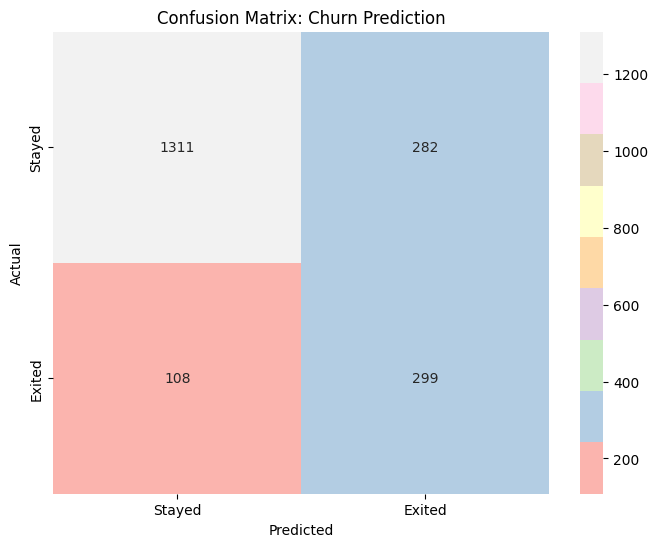

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Pastel1',
    xticklabels=['Stayed', 'Exited'],
    yticklabels=['Stayed', 'Exited']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Churn Prediction')
plt.show()

/tmp/ipykernel_6608/1426281170.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


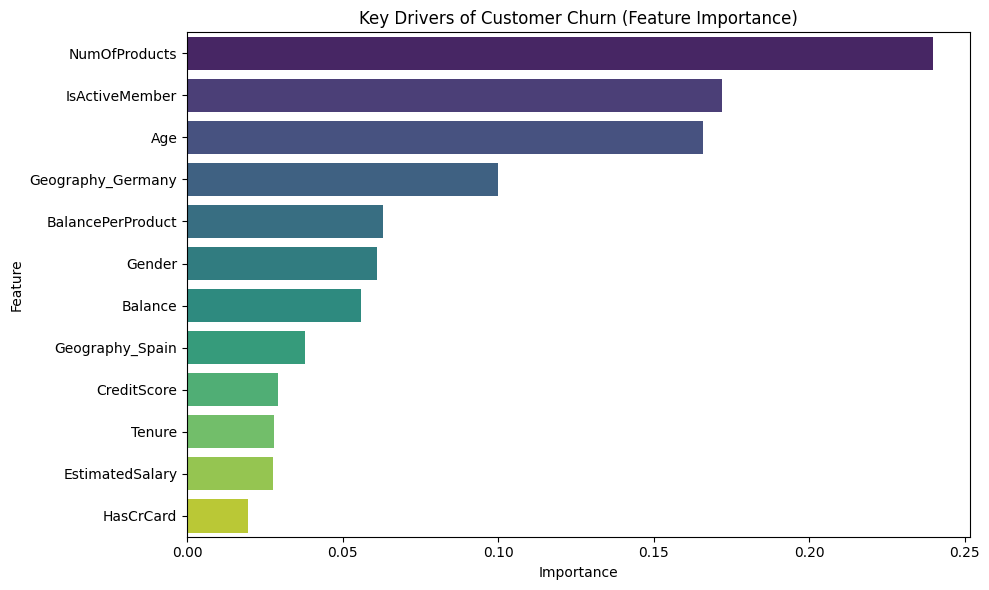

In [ ]:
pip install shap matplotlib seaborn

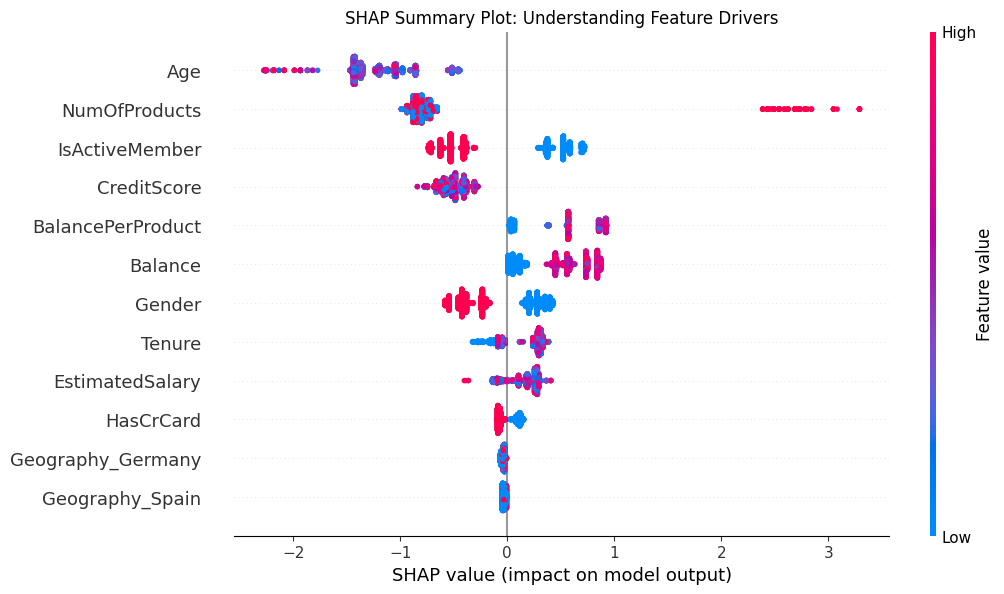

In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1. Initialize the SHAP explainer specifically for Tree models
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values on the *unscaled* test data
# We use unscaled so the interpretation of "Age" or "Balance" makes sense.
shap_values = explainer.shap_values(X_test)

# 3. Increase figure quality
plt.figure(figsize=(12, 8), dpi=100)
plt.title("SHAP Summary Plot: Understanding Feature Drivers")

# 4. Generate the beeswarm scatter plot
# The 'plot_type' default is beeswarm.
shap.summary_plot(shap_values, X_test, show=False)

# Optional customization
plt.gcf().set_size_inches(12, 6)
plt.show()

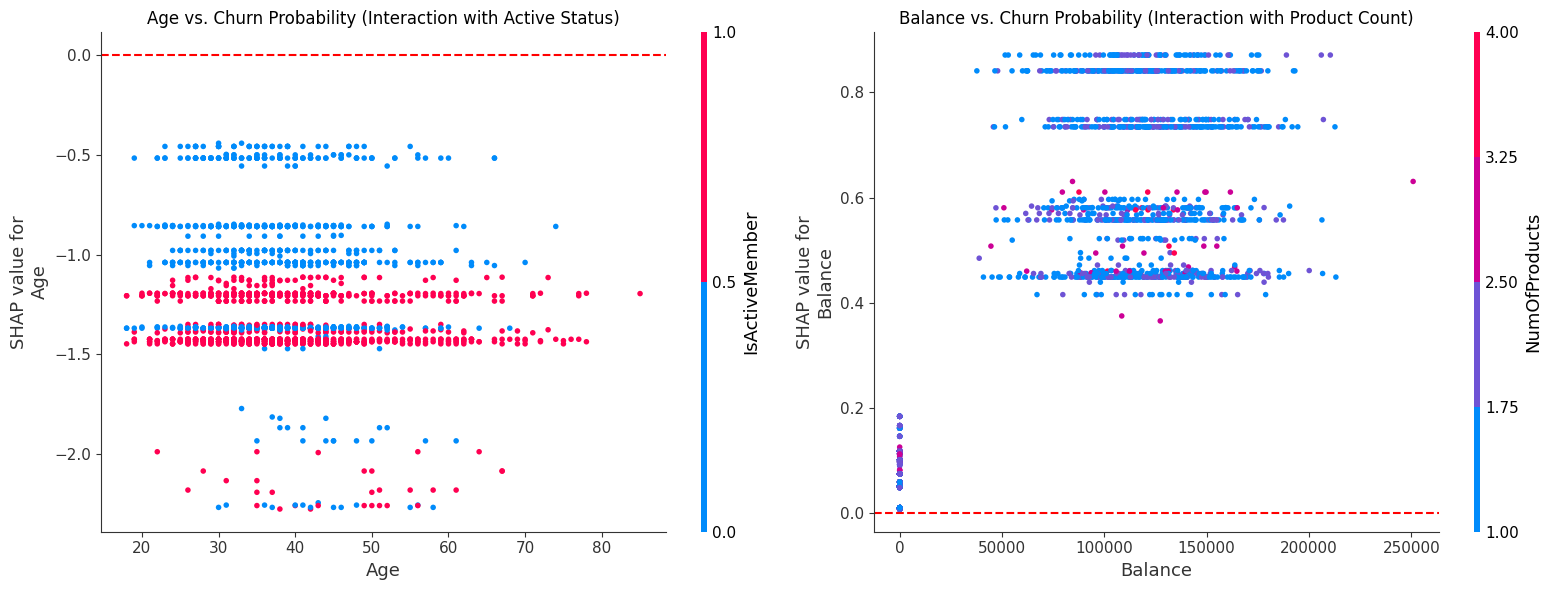

In [ ]:

fig, ax = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# Dependence 1: Age
# How Age specifically interacts with its contribution to Churn probability
shap.dependence_plot("Age", shap_values, X_test, ax=ax[0], show=False, interaction_index="IsActiveMember")
ax[0].set_title("Age vs. Churn Probability (Interaction with Active Status)")
ax[0].axhline(y=0, color='r', linestyle='--')

# Dependence 2: Balance
shap.dependence_plot("Balance", shap_values, X_test, ax=ax[1], show=False, interaction_index="NumOfProducts")
ax[1].set_title("Balance vs. Churn Probability (Interaction with Product Count)")
ax[1].axhline(y=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

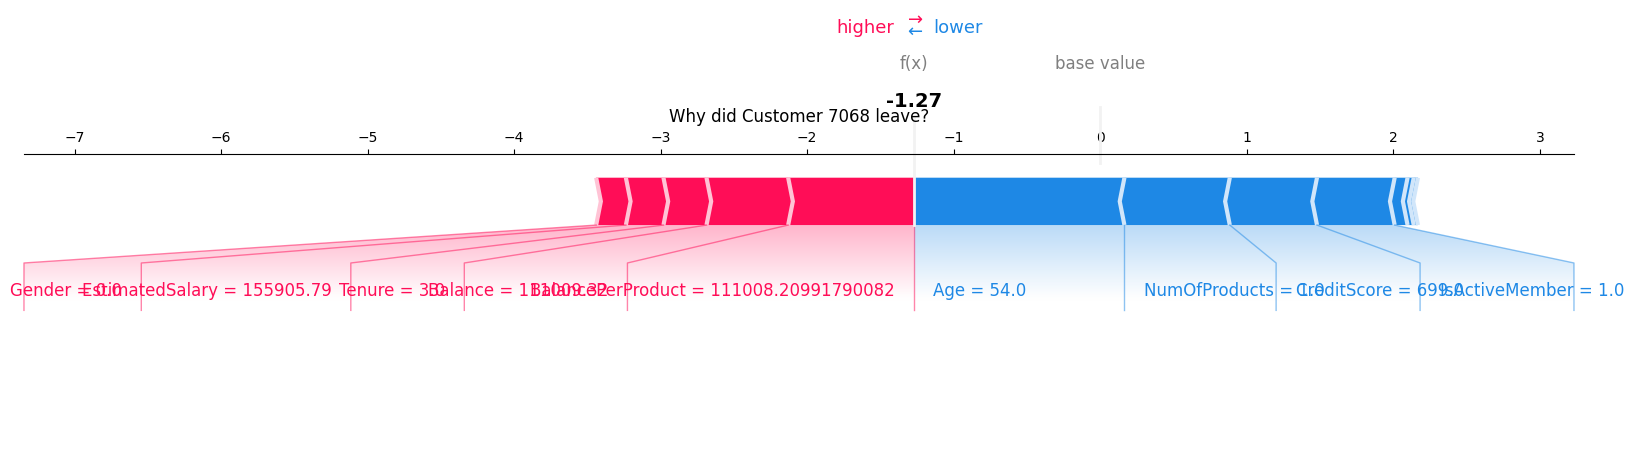

In [ ]:

high_risk_customer_index = y_test[y_test == 1].index[0]
# Get the base value
expected_value = explainer.expected_value

# Find the SHAP values just for this one customer
individual_shap_values = shap_values[X_test.index.get_loc(high_risk_customer_index)]

# Generate the Force Plot (local visualization)
shap.initjs()
shap.force_plot(
    expected_value,
    individual_shap_values,
    X_test.loc[high_risk_customer_index],
    matplotlib=True, # Set to False for interactive JS
    show=False
)
plt.gcf().set_size_inches(20, 4)
plt.title(f"Why did Customer {high_risk_customer_index} leave?")
plt.show()